In [111]:
import pandas as pd
import matplotlib as plt


In [153]:
import matplotlib as plt

In [ ]:
df = pd.read_csv('conflitos.csv')

In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2752 entries, 0 to 2751
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   conflict_id           2752 non-null   int64  
 1   location              2752 non-null   object 
 2   side_a                2752 non-null   object 
 3   side_a_id             2752 non-null   object 
 4   side_a_2nd            455 non-null    object 
 5   side_b                2752 non-null   object 
 6   side_b_id             2752 non-null   object 
 7   side_b_2nd            143 non-null    object 
 8   incompatibility       2752 non-null   int64  
 9   territory_name        1551 non-null   object 
 10  year                  2752 non-null   int64  
 11  intensity_level       2752 non-null   int64  
 12  cumulative_intensity  2752 non-null   int64  
 13  type_of_conflict      2752 non-null   int64  
 14  start_date            2752 non-null   object 
 15  start_prec           

In [178]:
df.head()

,conflict_id,location,side_a,side_a_id,side_a_2nd,side_b,side_b_id,side_b_2nd,incompatibility,territory_name,...,ep_end,ep_end_date,ep_end_prec,gwno_a,gwno_a_2nd,gwno_b,gwno_b_2nd,gwno_loc,region,version
0,11342,India,Government of India,141,NaN,GNLA,1163,NaN,territory,Garoland,...,1,2012-12-21,NaN,750,NaN,NaN,NaN,750,3,25.1
1,11342,India,Government of India,141,NaN,GNLA,1163,NaN,territory,Garoland,...,1,2014-11-27,NaN,750,NaN,NaN,NaN,750,3,25.1
2,11343,"Egypt, Israel",Government of Egypt,117,NaN,Government of Israel,121,NaN,territory,Suez/Sinai,...,1,1967-06-10,NaN,651,NaN,666,NaN,"651, 666",2,25.1
3,11343,"Egypt, Israel",Government of Egypt,117,NaN,Government of Israel,121,NaN,territory,Suez/Sinai,...,0,NaN,NaN,651,NaN,666,NaN,"651, 666",2,25.1
4,11343,"Egypt, Israel",Government of Egypt,117,NaN,Government of Israel,121,NaN,territory,Suez/Sinai,...,1,1970-08-07,NaN,651,NaN,666,NaN,"651, 666",2,25.1


In [115]:
df['incompatibility'] = df['incompatibility'].replace(1, 'territory')
df['incompatibility'] = df['incompatibility'].replace(2, 'government')
df['incompatibility'] = df['incompatibility'].replace(3, 'government and territory')

In [191]:
df['type_of_conflict'] = df['type_of_conflict'].replace(1, 'extrasystemic')
df['type_of_conflict'] = df['type_of_conflict'].replace(2, 'interstate')
df['type_of_conflict'] = df['type_of_conflict'].replace(3, 'intrastate')
df['type_of_conflict'] = df['type_of_conflict'].replace(4, 'internationalized intrastate')

In [119]:
df['intensity_level'] = df['intensity_level'].replace(1, 'minor')
df['intensity_level'] = df['intensity_level'].replace(2, 'war')

In [120]:
#qual é o motivo mais comum de guerra no mundo?
territorio = df[df['incompatibility'] == 'territory']['incompatibility'].count()
governo = df[df['incompatibility'] == 'government']['incompatibility'].count()
ambos = df[df['incompatibility'] == 'government and territory']['incompatibility'].count()
print(f'conflitos por territorio: {territorio}')
print(f'conflitos por governo: {governo}')
print(f'conflitos por ambos: {ambos}')

conflitos por territorio: 1524
conflitos por governo: 1201
conflitos por ambos: 27


array([<Axes: ylabel='count'>], dtype=object)

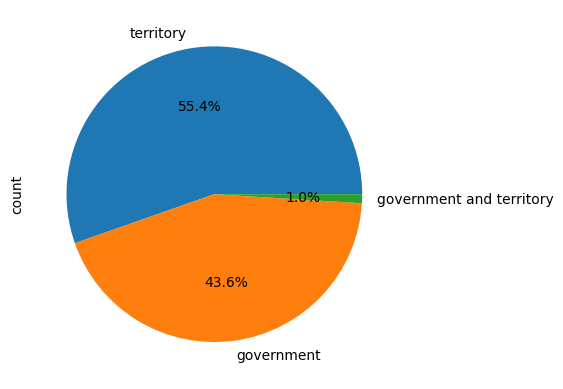

In [121]:
incompatibilidade = df['incompatibility'].value_counts()
incompatibilidade.plot(kind= 'pie', subplots=True, autopct='%1.1f%%')

In [122]:
#qual é o ano mais recente?

ano = df['year'].max()
print(ano)

2024


In [146]:
#nos ultimos 15 anos, o mundo está mais pacifico?
guerras_recentes = df[(df['year'] > 2010) & (df['intensity_level'] == 'war')]
print("guerras dos ultimos anos")
guerras_recentes.groupby('year')['conflict_id'].nunique()

guerras dos ultimos anos


year
2011     7
2012     6
2013     7
2014    13
2015    11
2016    12
2017    10
2018     6
2019     7
2020     8
2021     5
2022     8
2023     9
2024    11
Name: conflict_id, dtype: int64

In [ ]:
filtro = df[(df['intensity_level']== 'minor') & (df['cumulative_intensity'] == 1) & (df['year'] == 2024)]
print("Conflitos menores que a guerra e com mais de 1000 mortes em 2024")
filtro.groupby('location')['conflict_id'].nunique().sort_values(ascending= False)

Conflitos menores que a guerra e com mais de 1000 mortes em 2024


location
Myanmar (Burma)             4
Cameroon                    2
DR Congo (Zaire)            2
India                       2
Philippines                 2
Nigeria                     2
Niger                       2
Mali                        2
Afghanistan                 2
Ethiopia                    1
Colombia                    1
Burundi                     1
Central African Republic    1
Burkina Faso                1
Iran, Israel                1
Iraq                        1
Indonesia                   1
Mozambique                  1
Iran                        1
Pakistan                    1
Rwanda                      1
Syria                       1
Thailand                    1
Turkey                      1
Yemen (North Yemen)         1
Name: conflict_id, dtype: int64

In [ ]:
#tipo de conflito mais comum
df.groupby('type_of_conflict')['conflict_id'].nunique().sort_values(ascending= False)

type_of_conflict
intrastate                      213
internationalized intrastate     81
interstate                       52
extrasystemic                    21
Name: conflict_id, dtype: int64

In [208]:
#1= extrasystemic (between a state and a non-state 
# group outside its own territory, where the
# government side is fighting to retain control of a
# territory outside the state system)
print("paises mais envolvidos em guerras extrasistemicas: ")
extrasistemica = df[df['type_of_conflict'] == "extrasystemic"]
pais = extrasistemica.groupby('side_a')['conflict_id'].nunique().sort_values(ascending = False)
pais.head(5)

paises mais envolvidos em guerras extrasistemicas: 


side_a
Government of France            9
Government of United Kingdom    6
Government of Portugal          3
Government of Netherlands       1
Government of Spain             1
Name: conflict_id, dtype: int64

In [ ]:
#2= interstate (both sides are states in the Gleditsch
# and Ward membership system).
print("paises mais envolvidos em guerras entre Estados como lado A")
interstate = df[df['type_of_conflict'] == 'interstate']
pais = interstate.groupby('side_a')['conflict_id'].nunique().sort_values(ascending= False)
pais.head(5)

paises mais envolvidos em guerras entre Estados


side_a
Government of China                   5
Government of Afghanistan             3
Government of Egypt                   3
Government of Chad                    2
Government of Cambodia (Kampuchea)    2
Name: conflict_id, dtype: int64

In [ ]:
#ranking por anos de guerra acumulados
paises = df[df['intensity_level'] == 'war']
top3 = paises['location'].value_counts()
print("países que mais acumulam anos de guerra:")
top3.head(5)

países que mais acumulam anos de guerra


location
Myanmar (Burma)    52
Afghanistan        45
Sudan              38
Ethiopia           35
Angola             25
Name: count, dtype: int64

In [133]:
#conflitos unicos
print("\nRanking por qtd de conflitos distintos:")
ranking_conflitos = paises.groupby('location')['conflict_id'].nunique().sort_values(ascending=False)
print(ranking_conflitos.head(5))


Ranking por qtd de conflitos distintos:
location
Ethiopia                 6
Indonesia                4
Myanmar (Burma)          4
Russia (Soviet Union)    3
Nigeria                  3
Name: conflict_id, dtype: int64


In [135]:
#no pais top 1 que teve mais guerra, qual foi o motivo principal?
pais = df[(df['intensity_level'] == 'war') & (df['location'] == 'Myanmar (Burma)')]
top1 = pais.groupby('incompatibility')['conflict_id'].nunique().sort_values(ascending= False)
print("No país que teve mais guerra, qual foi a maior incompatibilidade? \n")
print(top1)

No país que teve mais guerra, qual foi a maior incompatibilidade? 

incompatibility
territory     3
government    1
Name: conflict_id, dtype: int64


In [ ]:
#vezes em que israel é mencionado em guerras
israel = df[(df['intensity_level'] == 'war') & (
    (df['side_a'].str.contains('Government of Israel', na=False)) |
    (df['side_b'].str.contains('Government of Israel', na=False)) |
    (df['side_a_2nd'].str.contains('Government of Israel', na=False)) |
    (df['side_b_2nd'].str.contains('Government of Israel', na=False))
    )]
print(f"Israel aparece {israel['conflict_id'].nunique()} vezes como uma das partes de guerras")


Israel aparece 7 vezes como uma das partes de guerras


In [ ]:
#quantos % de guerra do banco os EUA se meteram?
total_guerras = df[df['intensity_level']== 'war']['conflict_id'].nunique()
filtro_eua = (df['intensity_level'] == 'war') & (
    (df['side_a'].str.contains('Government of United States', na=False)) | 
    (df['side_b'].str.contains('Government of United States', na=False)) |
    (df['side_a_2nd'].str.contains('Government of United States', na=False)) | 
    (df['side_b_2nd'].str.contains('Government of United States', na=False))
)
guerras_eua = df[filtro_eua]['conflict_id'].nunique()

porcentagem = (guerras_eua / total_guerras)*100
print(f"Total de guerras no banco {total_guerras}")
print(f"Guerras com participação dos EUA: {guerras_eua}")
print(f"Porcentagem de guerras que os EUA se meteram {porcentagem:.2f}%")

Total de guerras no banco 132
Guerras com participação dos EUA: 19
Porcentagem de guerras que os EUA se meteram 14.39%
